In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ============================
# 1) Load data
# ============================
df = pd.read_excel("data/dataframe_processed.xlsx")

# =========================

# =========================
# 2) 全局设置
# =========================
severity_order = ['Low', 'Medium', 'High']
palette = {
    "Low": "#4C9F70",      # muted green (safe, stable)
    "Medium": "#D4B483",   # desaturated sand / khaki
    "High": "#C94A4A",     # muted red (hazard, not aggressive)
}

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.linewidth": 1.0
})


# =========================
# 3) 工具函数：列名容错匹配
# =========================
def _normalize_col(s: str) -> str:
    """统一列名格式：小写 + 去掉空格/下划线/连字符等"""
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())

def find_col(df: pd.DataFrame, candidates):
    """
    在 df.columns 里，从一组候选列名中找到最匹配的那一个（容错：空格/下划线/连字符/大小写）
    找不到返回 None
    """
    norm_map = {_normalize_col(c): c for c in df.columns}
    for cand in candidates:
        key = _normalize_col(cand)
        if key in norm_map:
            return norm_map[key]
    return None


# =========================
# 4) 类别特征堆叠比例图
# =========================
def plot_category_severity(ax, df, feature_col, severity_col, title, top_k=12):
    """
    feature_col: 实际存在于 df 的列名（类别特征）
    severity_col: 实际存在于 df 的列名（Severity）
    top_k: 类别太多时只展示 top_k，其余合并为 'Others'
    """
    # 只保留必要列，并把缺失值显式标出来
    tmp = df[[feature_col, severity_col]].copy()
    tmp[feature_col] = tmp[feature_col].astype(str).fillna("Missing").replace("nan", "Missing")
    tmp[severity_col] = tmp[severity_col].astype(str)

    # 合并稀有类别：只保留 top_k 个最常见的类别，其余归为 Others
    vc = tmp[feature_col].value_counts()
    keep = set(vc.head(top_k).index)
    tmp[feature_col] = tmp[feature_col].where(tmp[feature_col].isin(keep), other="Others")

    # 统计数量
    count_df = (
        tmp.groupby([feature_col, severity_col])
        .size()
        .reset_index(name='Count')
    )

    # 统一 Severity 顺序（如果你的 Severity 不是 Low/Medium/High，也不会崩，只是顺序按出现）
    if set(severity_order).issubset(set(tmp[severity_col].unique())):
        count_df[severity_col] = pd.Categorical(count_df[severity_col], categories=severity_order, ordered=True)
        col_order = severity_order
    else:
        # 回退：用数据中出现的顺序
        col_order = list(pd.unique(tmp[severity_col]))
        count_df[severity_col] = pd.Categorical(count_df[severity_col], categories=col_order, ordered=True)

    # 比例
    count_df['Proportion'] = (
        count_df['Count'] /
        count_df.groupby(feature_col)['Count'].transform('sum')
    )

    pivot = (
        count_df.pivot(index=feature_col, columns=severity_col, values='Proportion')
        .fillna(0)
    )

    colors = [palette.get(s, None) for s in col_order]  # 若不是 Low/Medium/High，就用默认颜色(None)
    pivot[col_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='black',
        linewidth=0.6
    )

    ax.set_title(title)
    ax.set_ylabel('Proportion')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=0)
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()



# =========================
# 5) 主逻辑：自动找列 + 画 2x3 子图
# =========================
# 关键列（Severity）
severity_col = find_col(df, ["Severity", "severity", "SI_level", "Severity_Level", "SeverityClass"])
if severity_col is None:
    raise KeyError(f"找不到 Severity 列。你当前列名有：{list(df.columns)}")

# 数值列（容量）
capacity_col = find_col(df, ["Cell-Capacity-Ah", "Cell Capacity Ah", "Capacity(Ah)", "Capacity_Ah", "CellCapacityAh"])

# 类别列候选（你可以按你的真实列名继续加）
feature_candidates = [
    ("Geometry", ["Geometry", "FormFactor", "Cell-Geometry", "Cell Geometry"]),
    ("Trigger Mechanism", ["Trigger-Mechanism", "Trigger Mechanism", "Trigger", "Abuse", "Initiation"]),
    ("Manufacturer", ["Manufacturer", "Maker", "Vendor", "Mfr"]),
    ("Vent Structure", ["Vent-Structure", "Vent Structure", "Vent", "BV Actuated", "BurstValve", "BVActuated"]),
]

# 找到实际存在的列
resolved = []
for display_name, cands in feature_candidates:
    col = find_col(df, cands)
    resolved.append((display_name, col))


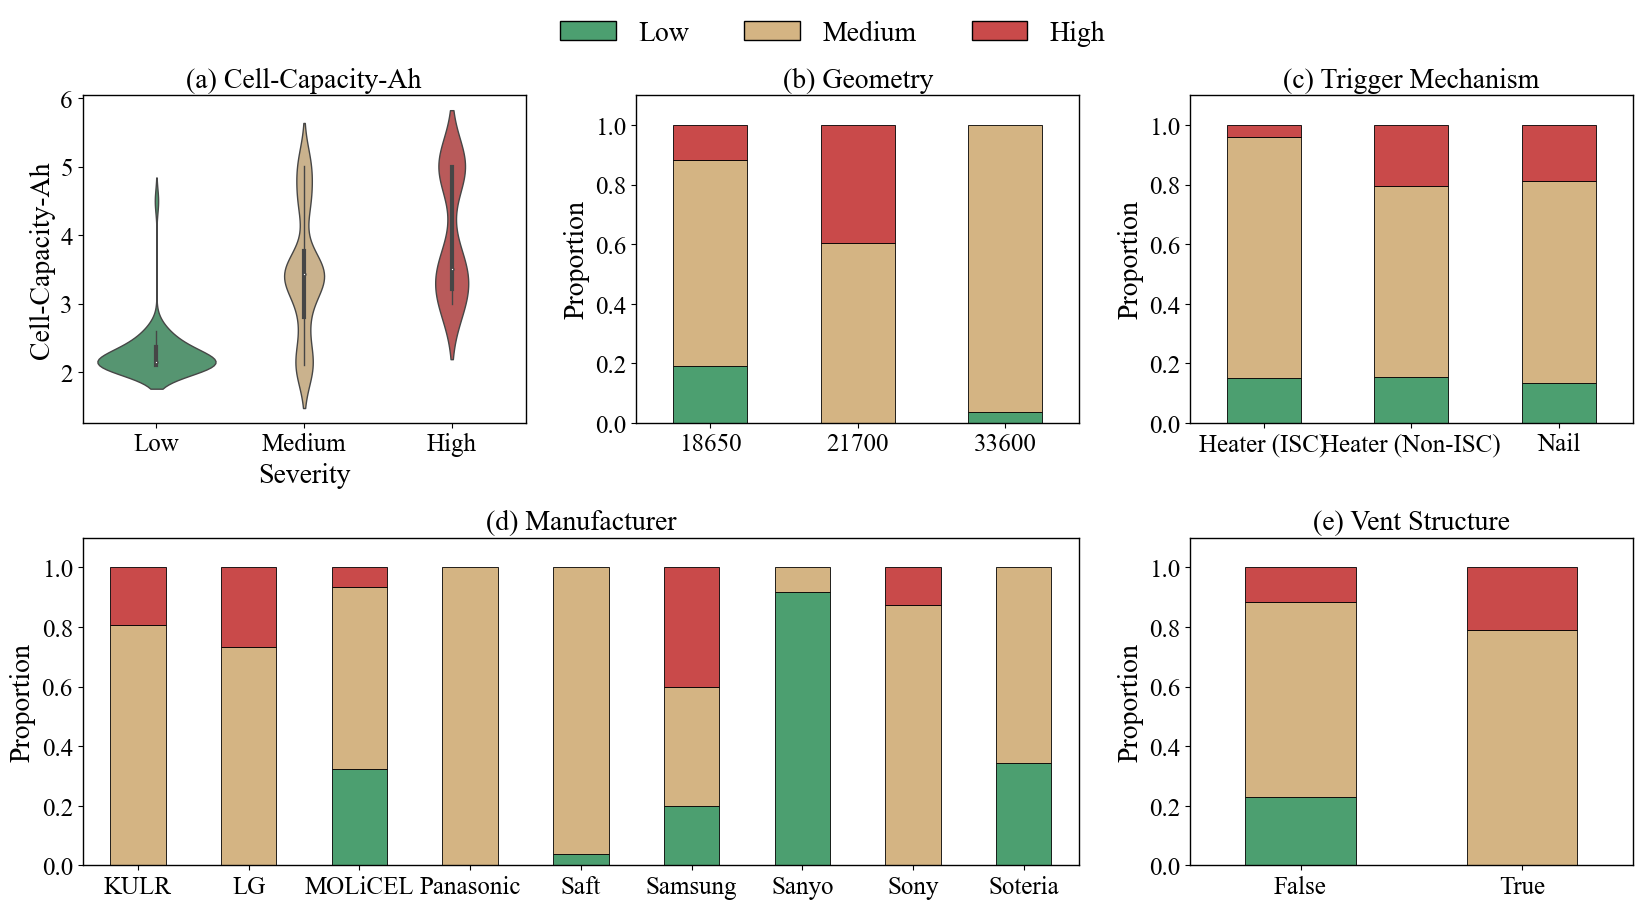

In [2]:
import matplotlib.gridspec as gridspec

# =========================
# 5) GridSpec 布局（关键修改点）
# =========================
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])      # (a)
ax2 = fig.add_subplot(gs[0, 1])      # (b)
ax3 = fig.add_subplot(gs[0, 2])      # (c)
ax4 = fig.add_subplot(gs[1, 0:2])    # (d) 跨两列
ax5 = fig.add_subplot(gs[1, 2])      # (e)

# =========================
# (a) 容量分布
# =========================
if capacity_col is not None:
    sns.violinplot(
        data=df,
        x=severity_col,
        y=capacity_col,
        order=severity_order if set(severity_order).issubset(set(df[severity_col].astype(str).unique())) else None,
        palette=palette,
        inner='box',
        linewidth=1,
        ax=ax1
    )
    ax1.set_title('(a) Cell-Capacity-Ah')
    ax1.set_xlabel('Severity')
    ax1.set_ylabel(capacity_col)
else:
    ax1.axis('off')
    ax1.text(0.5, 0.5, "Missing: Cell-Capacity-Ah", ha='center', va='center')

# =========================
# (b)–(e) 类别特征
# =========================
axes_map = [ax2, ax3, ax4, ax5]
panel_labels = ['(b)', '(c)', '(d)', '(e)']

for ax, (disp, col), label in zip(axes_map, resolved, panel_labels):
    if col is None:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{label} Missing column:\n{disp}", ha='center', va='center')
    else:
        plot_category_severity(
            ax, df,
            feature_col=col,
            severity_col=severity_col,
            title=f"{label} {disp}",
            top_k=12
        )

from matplotlib.patches import Patch

# 构造 legend 元素（手动指定颜色和标签）
legend_handles = [
    Patch(facecolor=palette['Low'],    edgecolor='black', label='Low'),
    Patch(facecolor=palette['Medium'], edgecolor='black', label='Medium'),
    Patch(facecolor=palette['High'],   edgecolor='black', label='High'),
]

# Figure 级 legend
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98),  # 控制整体位置（可微调）
    #title='Severity'
)


plt.tight_layout()
plt.savefig("imgs/plot/Distribution.png", dpi=600, bbox_inches="tight")
plt.show()
